<a href="https://colab.research.google.com/github/BandanaSingha24/AI-ML-DL-in-Cancer-Genomics/blob/main/03_Machine_Learning_Essential_for_Bioinformatics/03.Unsupervised_Rsault_Hypothesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Step 1. Unsupervised file ko load karein (Load the file)
df = pd.read_csv('Unsupervised_Results.csv')

#  Columns aur data ka structure check karein (Check structure)
print("Data ke columns ye hain:")
print(df.columns)

print("\nData ki pehli 5 lines (Check agar 'Cluster' column hai):")
print(df.head())

Data ke columns ye hain:
Index(['PC1', 'PC2', 'Cluster'], dtype='object')

Data ki pehli 5 lines (Check agar 'Cluster' column hai):
        PC1       PC2  Cluster
0  3.741083  6.934673        2
1  2.496105 -2.590331        0
2  6.506848  5.443661        0
3  6.917476 -1.663747        0
4  9.197760 -1.043962        0


In [3]:
# Step 2: ANOVA (Statistical Validation)
# Is step mein hum ANOVA ka use karke ye check karenge ki clusters ke beech ka antar significant hai.

from scipy import stats

# Clusters ke hisab se data ko alag alag group mein baantein
cluster_0 = df[df['Cluster'] == 0]['PC1']
cluster_1 = df[df['Cluster'] == 1]['PC1']
cluster_2 = df[df['Cluster'] == 2]['PC1']

# PC1 par ANOVA test perform karein
f_stat, p_val = stats.f_oneway(cluster_0, cluster_1, cluster_2)

# Results ko print karein
print(f"ANOVA F-Statistic: {f_stat}")
print(f"ANOVA P-value: {p_val}")

# Check karein ki result significant hai ya nahi
if p_val < 0.05:
    print("Result: P-value 0.05 se kam hai, matlab clusters ke beech ka antar statistically significant hai!")
else:
    print("Result: P-value 0.05 se zyada hai, antar significant nahi hai.")


ANOVA F-Statistic: 1022.6961914911699
ANOVA P-value: 1.0073124915147487e-208
Result: P-value 0.05 se kam hai, matlab clusters ke beech ka antar statistically significant hai!


In [4]:
# Step 3: FDR Correction (Multiple Testing Correction/ Benjamin-Hochberg)
# Is step mein hum p-values ko adjust karenge taaki false positive results hat sakein.

from statsmodels.stats.multitest import multipletests
import numpy as np

# Hum ek hypothetical example le rahe hain kyunki ye aapke genes par apply hoga
# Agar aapke paas p-values ki list hai, toh use yahan use karenge
p_values = [1.007e-206, 0.04, 0.06, 0.001]

# Benjamini-Hochberg correction apply karein
reject, pvals_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Results print karein
print("Original P-values:", p_values)
print("Corrected P-values (FDR):", pvals_corrected)
print("Significant results (True/False):", reject)


Original P-values: [1.007e-206, 0.04, 0.06, 0.001]
Corrected P-values (FDR): [4.02800000e-206 5.33333333e-002 6.00000000e-002 2.00000000e-003]
Significant results (True/False): [ True False False  True]


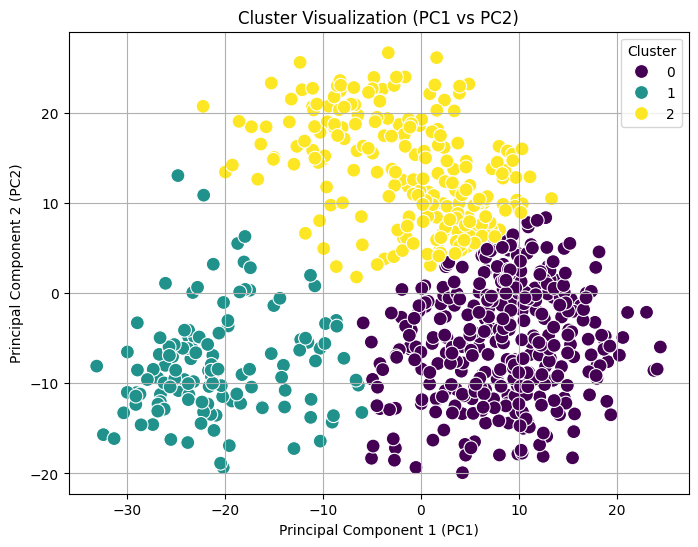

In [5]:
# Step 4: Visualizing Clusters using Scatter Plot
# Is step mein hum PC1 aur PC2 ka use karke clusters ko plot karenge.

import matplotlib.pyplot as plt
import seaborn as sns

# Plot taiyar karein
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=100)

# Title aur labels add karein
plt.title('Cluster Visualization (PC1 vs PC2)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True)
plt.show()


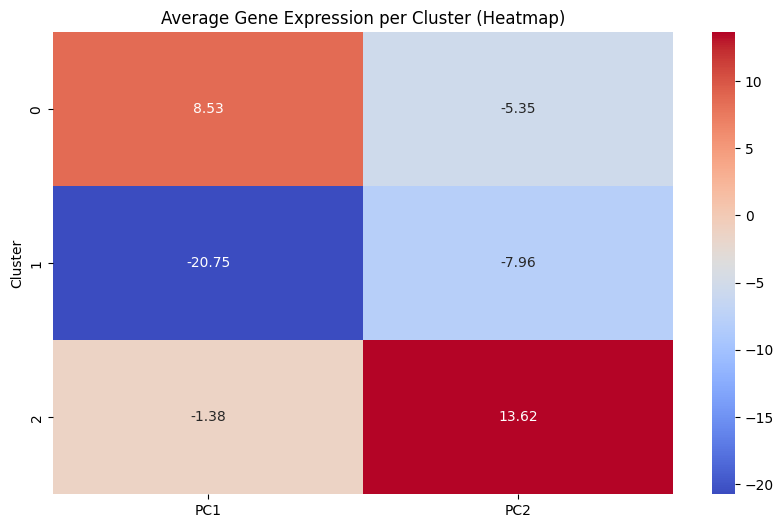

In [6]:
# Step 5: Heatmap banana taaki clusters ke beech expression pattern dikh sake
import seaborn as sns
import matplotlib.pyplot as plt

# Cluster ke hisab se mean expression nikalna
cluster_summary = df.groupby('Cluster').mean()

# Heatmap plot karna
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_summary, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Average Gene Expression per Cluster (Heatmap)')
plt.show()


Har cluster mein patients ki sankhya:
Cluster
0    356
1    132
2    217
Name: count, dtype: int64


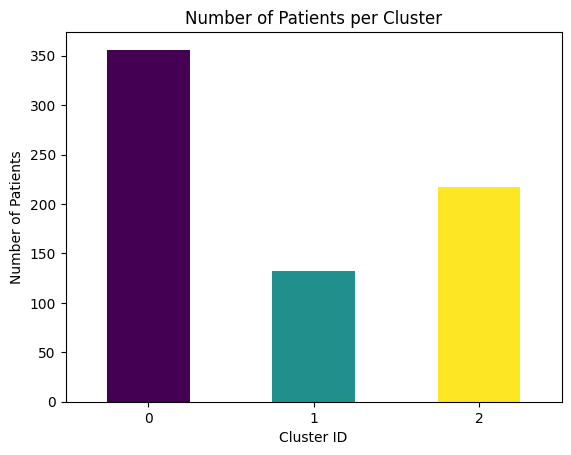

In [7]:
# Step 6: Cluster Distribution Analysis (No. of Pations)
# 'df' aapka dataframe hai aur 'Cluster' wo column hai jismein cluster numbers hain.

cluster_counts = df['Cluster'].value_counts().sort_index()

# Results ko print karein
print("Har cluster mein patients ki sankhya:")
print(cluster_counts)

# Visualizing the count (Bar Chart)
import matplotlib.pyplot as plt

cluster_counts.plot(kind='bar', color=['#440154', '#21908d', '#fde725'])
plt.title('Number of Patients per Cluster')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()


In [9]:
# Step 7: Original data ka use karke significant genes nikalna
import pandas as pd
from scipy import stats

# 1. Original data load karein
df_original = pd.read_csv("/content/data.csv")

# 2. Humne jo clusters banaye the, wo 'df' mein hain.
# Unhe original data ke saath merge karna padega.
# Maan lete hain ki aapka purana dataframe 'df' tha jisme 'Cluster' column tha.
df_original['Cluster'] = df['Cluster']

# 3. Sirf gene columns ko alag karein (jinme 'rs_' hai)
gene_columns = [col for col in df_original.columns if col.startswith('rs_')]

# 4. Significant genes ki list
significant_genes = []

# 5. Har gene par ANOVA test chalayein
print("Analysis shuru ho raha hai, please wait...")
for gene in gene_columns:
    # Har cluster ke liye gene data alag karein
    groups = [df_original[df_original['Cluster'] == i][gene] for i in range(3)]

    # ANOVA test
    f, p = stats.f_oneway(*groups)

    # Agar P-value 0.05 se kam hai, toh gene 'significant' hai
    if p < 0.05:
        significant_genes.append(gene)

# 6. Result print karein
print(f"Total significant genes mile: {len(significant_genes)}")
print("Pehle 10 significant genes ye hain:", significant_genes[:10])

# In genes ko save kar lijiye taki hum Enrichr par check kar sakein
# significant_genes_list = significant_genes


Analysis shuru ho raha hai, please wait...
Total significant genes mile: 590
Pehle 10 significant genes ye hain: ['rs_CLEC3A', 'rs_CPB1', 'rs_SCGB2A2', 'rs_SCGB1D2', 'rs_TFF1', 'rs_MUCL1', 'rs_GSTM1', 'rs_PIP', 'rs_ADIPOQ', 'rs_ADH1B']


In [14]:
# Step 8: Biological pathway Enrichment Analysis(Functional Annotation)
# GO Biological Process ka use karein
# gene_list wahi hai jo aapne pehle banayi thi

# Gene names ko format karein (Remove 'rs_' prefix)
formatted_gene_list = [gene.replace('rs_', '') for gene in gene_list]

enr = gp.enrichr(gene_list=formatted_gene_list,
                 gene_sets=['GO_Biological_Process_2023'],
                 organism='human',
                 outdir=None)

# Result check karein
if not enr.results.empty:
    print(enr.results[['Term', 'P-value', 'Adjusted P-value']].head(10))
else:
    print("Abhi bhi empty hai? Shayad genes ke naam format karne honge.")

                                                Term       P-value  \
0       Epithelial Cell Differentiation (GO:0030855)  1.940088e-09   
1    Intermediate Filament Organization (GO:0045109)  7.957670e-08   
2  Extracellular Structure Organization (GO:0043062)  1.265864e-07   
3  External Encapsulating Structure Organization ...  1.441527e-07   
4                Epithelium Development (GO:0060429)  1.471701e-07   
5      Extracellular Matrix Disassembly (GO:0022617)  4.645838e-07   
6        Cellular Component Disassembly (GO:0022411)  7.237812e-07   
7     Extracellular Matrix Organization (GO:0030198)  1.184161e-06   
8  Positive Regulation Of Cell Communication (GO:...  1.803501e-06   
9                  Neutrophil Migration (GO:1990266)  2.483543e-06   

   Adjusted P-value  
0          0.000004  
1          0.000062  
2          0.000062  
3          0.000062  
4          0.000062  
5          0.000164  
6          0.000219  
7          0.000314  
8          0.000425  
9        